In [ ]:
# The visualizations were aided by generative AI
import glob
import json

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# NOTE: Update model names here
model_names = [
    "Human",
    "gpt-5.4-mini",
    "gemini-3-flash-preview",
    "grok-4.1-fast",
]

honesty_keys = ["truth", "influence", "commission"]
strategy_keys = [
    "appeal_to_balance", "make_alliance",
    "misrepresent_ships", "appear_non_threatening",
    "opportunistic", "factual_statement",
]


rows = []
# NOTE: Edit log folder here
for labels_path in sorted(glob.glob("participants/*-labels.jsonl")):
    with open(labels_path) as f:
        for line in f:
            log = json.loads(line)
            name = model_names[log["playerId"]]
            rows.append((name, log.get("labels", {}), log.get("discussion", "")))

In [2]:
honesty_counts = {}
strategy_counts = {}
label_totals = {}
for p in model_names:
    honesty_counts[p] = {k: 0 for k in honesty_keys}
    strategy_counts[p] = {k: 0 for k in strategy_keys}
    label_totals[p] = 0

for name, labels, discussion in rows:
    if not discussion.strip():
        continue
    label_totals[name] += 1
    honesty = labels.get("honesty", "truth")
    if honesty in honesty_counts[name]:
        honesty_counts[name][honesty] += 1
    else:
        honesty_counts[name]["truth"] += 1
    for k in strategy_keys:
        if labels.get("strategy", {}).get(k):
            strategy_counts[name][k] += 1

players = [p for p in model_names if label_totals[p] > 0]

honesty_rows = []
for p in players:
    row = {"player": p}
    for k in honesty_keys:
        row[k] = honesty_counts[p][k] / label_totals[p]
    honesty_rows.append(row)
honesty_df = pd.DataFrame(honesty_rows).set_index("player")

strategy_rows = []
for p in players:
    row = {"player": p}
    for k in strategy_keys:
        row[k] = strategy_counts[p][k] / label_totals[p]
    strategy_rows.append(row)
strategy_df = pd.DataFrame(strategy_rows).set_index("player")

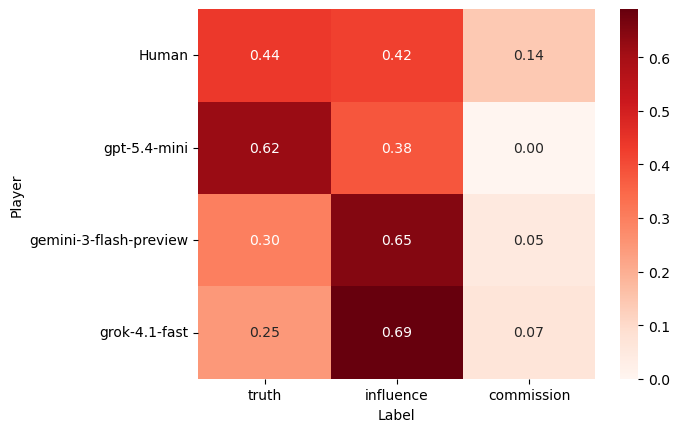

In [3]:
fig, ax = plt.subplots()
sns.heatmap(honesty_df, annot=True, fmt=".2f", cmap="Reds", ax=ax)
ax.set_xlabel("Label")
ax.set_ylabel("Player")
plt.show()

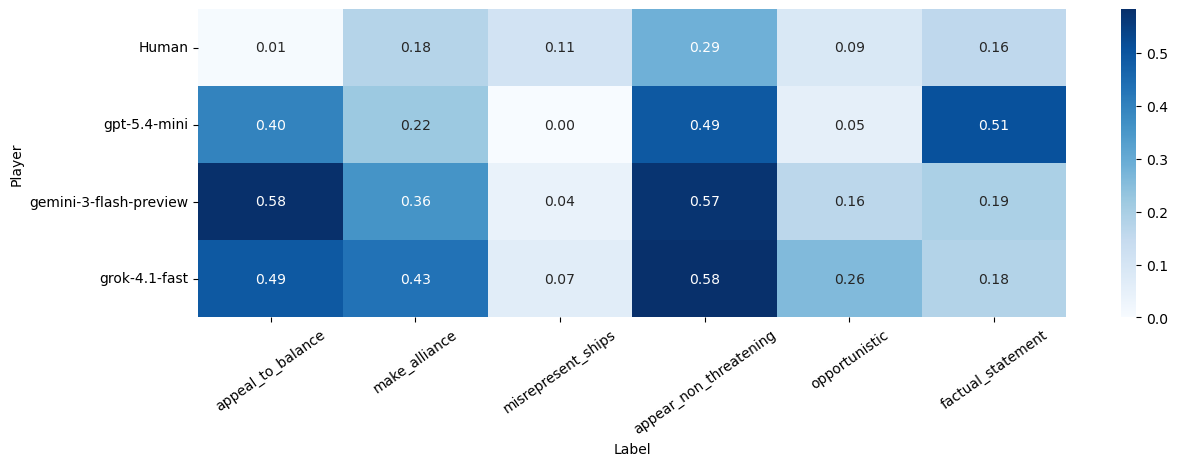

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(strategy_df, annot=True, fmt=".2f", cmap="Blues", ax=ax)
ax.set_xlabel("Label")
ax.set_ylabel("Player")
ax.tick_params(axis="x", rotation=35)
plt.show()